# Colab: SST preprocessing to GPT-2 Small sentiment-direction results

This notebook runs the repository's end-to-end reproduction workflow on a Colab GPU:

1. clone and install the project plus the reference SST source;
2. securely read `HF_TOKEN` from Colab Secrets;
3. preprocess Stanford Sentiment Treebank (SST) with Pythia-1.4B and optionally publish all generated dataset configurations to the Hugging Face Hub;
4. fit GPT-2 Small mean-difference, K-means, logistic-regression, PCA, DAS 1D/2D/3D, and random-control directions;
5. perform all-position directional patching on held-out ToyMovieReview and Pythia-filtered SST;
6. generate, inspect, plot, and download the saved results.

> The project's reproduction runner calls the package implementation directly. The notebook contains no separate fitting, patching, or metric logic.


## Before running

1. In Colab, choose **Runtime → Change runtime type → T4 GPU** (or a larger GPU).
2. Open the **Secrets** panel (key icon), add a secret named `HF_TOKEN`, and enable notebook access. Use a Hugging Face user access token with **write** permission if `PUSH_SST_TO_HUB = True`.
3. Do not paste an `hf_...` token into any code cell. This notebook supplies the secret only to the publishing subprocess and never prints or stores it in notebook output.
4. The smoke run is a pipeline check. It is not a reportable reproduction. The full run scans all 13 GPT-2 Small residual boundaries and is substantially more expensive, especially for DAS.


In [1]:
# User settings
USE_GOOGLE_DRIVE = True  # Persist fitted direction checkpoints across Colab sessions.

RUN_SST_PREPROCESSING = True
PUSH_SST_TO_HUB = True
HF_DATASET_REPO_ID = "kokolamba/sentiment-manifold-sst-pythia-1.4b"  # Blank => <your-HF-user>/sentiment-manifold-sst-pythia-1.4b
PUBLISH_PRIVATE = True
SST_BATCH_SIZE = 32  # Reduce to 8 or 4 if Pythia preprocessing runs out of GPU memory.

RUN_SMOKE = True
RUN_FULL_REPRODUCTION = False  # Set True only after the smoke run succeeds.
FULL_METHODS = [
    "mean_diff",
    "kmeans",
    "logistic_regression",
    "pca",
    "das",
    "das2d",
    "das3d",
    "random",
]
DEVICE = "cuda"


## 1. Clone and install the two repositories

The SST files are read from the authors' reference repository. Its revision is pinned below so the input files do not silently change. If a checkout already exists in the Colab runtime, it is reused.


In [ ]:
from pathlib import Path
import os
import shlex
import subprocess
import sys

COLAB_ROOT = Path("/content")
PROJECT_ROOT = COLAB_ROOT / "sentiment-manifold"
REFERENCE_ROOT = COLAB_ROOT / "eliciting-latent-sentiment"
PROJECT_URL = "https://github.com/Adefioye/sentiment-manifold.git"
REFERENCE_URL = "https://github.com/curt-tigges/eliciting-latent-sentiment.git"
REFERENCE_REVISION = "037cbc9c18867e03da14ceace612ab7e0f9449f7"

# def checked_run(command, *, cwd=None, env=None):
#     command = [str(part) for part in command]
#     print("+", shlex.join(command))
#     return subprocess.run(command, cwd=cwd, env=env, check=True)

if not (PROJECT_ROOT / ".git").is_dir():
    checked_run(["git", "clone", PROJECT_URL, PROJECT_ROOT])
else:
    print(f"Reusing {PROJECT_ROOT}")

reference_was_cloned = not (REFERENCE_ROOT / ".git").is_dir()
if reference_was_cloned:
    checked_run(["git", "clone", REFERENCE_URL, REFERENCE_ROOT])
else:
    print(f"Reusing {REFERENCE_ROOT}")
if reference_was_cloned:
    checked_run(["git", "checkout", "--detach", REFERENCE_REVISION], cwd=REFERENCE_ROOT)
else:
    existing_reference_revision = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=REFERENCE_ROOT, text=True
    ).strip()
    if existing_reference_revision != REFERENCE_REVISION:
        raise RuntimeError(
            f"Existing reference checkout is {existing_reference_revision}, expected "
            f"{REFERENCE_REVISION}. Use a fresh Colab runtime rather than overwriting it."
        )

checked_run([sys.executable, "-m", "pip", "install", "-q", "-e", f"{PROJECT_ROOT}[notebooks]"])
os.chdir(PROJECT_ROOT)
print("Project revision:", subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, text=True).strip())
print("Reference revision:", subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REFERENCE_ROOT, text=True).strip())


+ git clone https://github.com/Adefioye/sentiment-manifold.git /content/sentiment-manifold
+ git clone https://github.com/curt-tigges/eliciting-latent-sentiment.git /content/eliciting-latent-sentiment
+ git checkout --detach 037cbc9c18867e03da14ceace612ab7e0f9449f7
+ /usr/bin/python3 -m pip install -q -e '/content/sentiment-manifold[notebooks]'
Project revision: f7624e89ce9a0c5a31af02ba1433c88029fbb1bc
Reference revision: 037cbc9c18867e03da14ceace612ab7e0f9449f7


In [19]:
def checked_run(command, *, cwd=None, env=None):
    command = [str(part) for part in command]
    print("+", shlex.join(command))

    process = subprocess.Popen(
        command,
        cwd=cwd,
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="")

    returncode = process.wait()
    if returncode != 0:
        raise RuntimeError(
            f"Command failed with exit code {returncode}: "
            f"{shlex.join(command)}"
        )

    return subprocess.CompletedProcess(command, returncode)

## 2. Verify the accelerator and choose storage locations

Lightweight CSV/JSON/PNG results stay on the Colab instance. Only reusable fitted directions are placed on Google Drive when enabled. The runner is resumable and uses configuration fingerprints to prevent incompatible checkpoints from being reused.


In [4]:
from pathlib import Path
import importlib
import subprocess
import sys

PROJECT_ROOT = Path("/content/sentiment-manifold")

assert (PROJECT_ROOT / "pyproject.toml").is_file(), (
    "Project was not cloned. Rerun the notebook's clone/install cell first."
)

# Show installation errors instead of suppressing them with -q.
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-e",
        f"{PROJECT_ROOT}[notebooks]",
    ],
    check=True,
)

# Make the editable source visible immediately without restarting the kernel.
project_src = str(PROJECT_ROOT / "src")
if project_src not in sys.path:
    sys.path.insert(0, project_src)

importlib.invalidate_caches()

import sentiment_manifold
print("Imported from:", sentiment_manifold.__file__)

Imported from: /content/sentiment-manifold/src/sentiment_manifold/__init__.py


In [5]:
import torch
from sentiment_manifold.storage import maybe_mount_google_drive

if DEVICE == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("CUDA is unavailable. Enable a GPU runtime in Colab before continuing.")

maybe_mount_google_drive(USE_GOOGLE_DRIVE)
CHECKPOINT_ROOT = (
    Path("/content/drive/MyDrive/sentiment-manifold/checkpoints")
    if USE_GOOGLE_DRIVE
    else PROJECT_ROOT / "checkpoints"
)
RESULT_ROOT = PROJECT_ROOT / "outputs" / "colab"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
RESULT_ROOT.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
print("Results:", RESULT_ROOT)
print("Direction checkpoints:", CHECKPOINT_ROOT)


Mounted at /content/drive
PyTorch: 2.11.0+cu128
GPU: NVIDIA L4
Results: /content/sentiment-manifold/outputs/colab
Direction checkpoints: /content/drive/MyDrive/sentiment-manifold/checkpoints


## 3. Securely validate the Hugging Face secret

The token is retrieved only at runtime from Colab Secrets. It is not assigned to a persistent environment variable, included in a command argument, or printed.


In [8]:
from getpass import getpass

_RUNTIME_SECRETS = {}

def get_colab_secret(name):
    if name not in _RUNTIME_SECRETS:
        value = getpass(f"Enter {name} (input hidden): ").strip()
        if not value:
            raise RuntimeError(f"{name} was not provided.")
        _RUNTIME_SECRETS[name] = value
    return _RUNTIME_SECRETS[name]

In [12]:
if PUSH_SST_TO_HUB:
    from huggingface_hub import HfApi

    _token = get_colab_secret("HF_TOKEN")
    _account = HfApi(token=_token).whoami()["name"]
    del _token
    print(f"Authenticated to Hugging Face as {_account}. Token value was not displayed.")
else:
    print("Hub publishing is disabled; no Hugging Face write token is required.")

Authenticated to Hugging Face as kokolamba. Token value was not displayed.


## 4. Preprocess SST with Pythia-1.4B and publish it

This creates both repository-supported binarizations and ten Hugging Face dataset configurations. The reproduction itself consumes `tigges_pythia_correct`, then reconstructs equal-GPT-2-token-length pairs locally.

Publishing defaults to a private dataset. The literal token is added only to a temporary child-process environment and removed immediately after the command returns. If preprocessing output already exists, this cell skips it to avoid overwriting a completed dataset. Use a fresh Colab runtime if you intentionally need to rebuild it.


In [13]:
SST_OUTPUT_DIR = PROJECT_ROOT / "data/processed/sst-pythia-1.4b"
SST_METADATA = SST_OUTPUT_DIR / "metadata.json"

if RUN_SST_PREPROCESSING and not SST_METADATA.exists():
    command = [
        sys.executable,
        "-m",
        "sentiment_manifold",
        "preprocess-sst",
        "--sst-root",
        REFERENCE_ROOT / "stanfordSentimentTreebank",
        "--output-dir",
        SST_OUTPUT_DIR,
        "--device",
        DEVICE,
        "--dtype",
        "auto",
        "--batch-size",
        str(SST_BATCH_SIZE),
        "--binarization",
        "both",
    ]
    child_env = None
    if PUSH_SST_TO_HUB:
        command.append("--push-to-hub")
        command.append("--private" if PUBLISH_PRIVATE else "--public")
        if HF_DATASET_REPO_ID.strip():
            command.extend(["--hub-repo-id", HF_DATASET_REPO_ID.strip()])
        child_env = os.environ.copy()
        child_env["HF_TOKEN"] = get_colab_secret("HF_TOKEN")
    try:
        checked_run(command, cwd=PROJECT_ROOT, env=child_env)
    finally:
        if child_env is not None:
            child_env.pop("HF_TOKEN", None)
            del child_env
elif SST_METADATA.exists():
    print(f"Reusing completed SST preprocessing at {SST_OUTPUT_DIR}")
else:
    raise FileNotFoundError(
        "Processed SST data is missing. Set RUN_SST_PREPROCESSING = True and run this cell."
    )


+ /usr/bin/python3 -m sentiment_manifold preprocess-sst --sst-root /content/eliciting-latent-sentiment/stanfordSentimentTreebank --output-dir /content/sentiment-manifold/data/processed/sst-pythia-1.4b --device cuda --dtype auto --batch-size 32 --binarization both --push-to-hub --private --hub-repo-id kokolamba/sentiment-manifold-sst-pythia-1.4b


In [14]:
import json

sst_metadata = json.loads(SST_METADATA.read_text())
print("Published repository:", sst_metadata.get("hub_repo_id", "not published in this run"))
print(json.dumps(sst_metadata["counts"], indent=2, sort_keys=True))
assert "tigges_pythia_correct" in sst_metadata["dataset_configs"]


Published repository: kokolamba/sentiment-manifold-sst-pythia-1.4b
{
  "source_sentences": 10929,
  "variants": {
    "neutral_removed": {
      "binarized": {
        "test": 1692,
        "train": 6368,
        "validation": 797
      },
      "directed_pairs": 406,
      "matched_pairs": 203,
      "pythia_correct_test": 1068,
      "pythia_incorrect_test": 624,
      "pythia_scored_test": 1692
    },
    "tigges": {
      "binarized": {
        "test": 2058,
        "train": 7864,
        "validation": 1007
      },
      "directed_pairs": 438,
      "matched_pairs": 219,
      "pythia_correct_test": 1236,
      "pythia_incorrect_test": 822,
      "pythia_scored_test": 2058
    }
  }
}


In [15]:
# Delete the token from memory after use to avoid accidental exposure in notebook outputs.
# _RUNTIME_SECRETS.clear()

## 5. Inspect GPT-2 Small tokenization

This downloads the pinned GPT-2 Small revision and records how much of ToyMovieReview remains single-token under its tokenizer.


In [16]:
checked_run(
    [
        sys.executable,
        "-m",
        "sentiment_manifold",
        "inspect-data",
        "--config",
        PROJECT_ROOT / "configs/reproduction.yaml",
        "--model",
        "gpt2-small",
        "--device",
        DEVICE,
    ],
    cwd=PROJECT_ROOT,
)


+ /usr/bin/python3 -m sentiment_manifold inspect-data --config /content/sentiment-manifold/configs/reproduction.yaml --model gpt2-small --device cuda


CompletedProcess(args=['/usr/bin/python3', '-m', 'sentiment_manifold', 'inspect-data', '--config', '/content/sentiment-manifold/configs/reproduction.yaml', '--model', 'gpt2-small', '--device', 'cuda'], returncode=0)

## 6. Run a cheap pipeline smoke test

The smoke configuration uses one residual boundary, two SST pairs, one DAS epoch, and five methods. It still exercises direction fitting, ToyMovieReview/SST pairing, patching, metrics, artifact saving, and plotting. Do not report smoke metrics as research results.


In [21]:
import pandas as pd

smoke_metrics = pd.read_csv(
    "/content/sentiment-manifold/outputs/colab/smoke/gpt2-small/metrics.csv"
)

display(
    smoke_metrics[
        [
            "method",
            "sst_corrupted_accuracy",
            "sst_clean_accuracy",
            "sst_patched_accuracy",
            "sst_logit_flip_percent",
            "sst_sign_flip_percent",
            "sst_logit_diff_percent",
        ]
    ]
)

,method,sst_corrupted_accuracy,sst_clean_accuracy,sst_patched_accuracy,sst_logit_flip_percent,sst_sign_flip_percent,sst_logit_diff_percent
0,mean_diff,0.5,0.5,0.75,NaN,0.0,-1791.514042
1,kmeans,0.5,0.5,0.75,NaN,0.0,-1791.514042
2,logistic_regression,0.5,0.5,0.75,NaN,0.0,-1983.089133
3,pca,0.5,0.5,0.50,NaN,0.0,-844.871795
4,das,0.5,0.5,0.50,NaN,0.0,-80.179080


In [22]:
from pathlib import Path

smoke_config = Path("/content/sentiment-manifold/configs/smoke.yaml")
contents = smoke_config.read_text()

if "sst_max_pairs: 2" not in contents:
    raise RuntimeError("Expected smoke configuration was not found.")

smoke_config.write_text(
    contents.replace("sst_max_pairs: 2", "sst_max_pairs: 32")
)

print("Updated:", smoke_config)

Updated: /content/sentiment-manifold/configs/smoke.yaml


In [23]:
SMOKE_OUTPUT_ROOT = RESULT_ROOT / "smoke"
SMOKE_RUN_DIR = SMOKE_OUTPUT_ROOT / "gpt2-small"

if RUN_SMOKE:
    checked_run(
        [
            sys.executable,
            "-m",
            "sentiment_manifold",
            "reproduce",
            "--config",
            PROJECT_ROOT / "configs/smoke.yaml",
            "--model",
            "gpt2-small",
            "--device",
            DEVICE,
            "--output-dir",
            SMOKE_OUTPUT_ROOT,
            "--checkpoint-dir",
            CHECKPOINT_ROOT,
        ],
        cwd=PROJECT_ROOT,
    )
    checked_run(
        [sys.executable, "-m", "sentiment_manifold", "plot", "--run-dir", SMOKE_RUN_DIR],
        cwd=PROJECT_ROOT,
    )
else:
    print("Smoke run disabled.")

+ /usr/bin/python3 -m sentiment_manifold reproduce --config /content/sentiment-manifold/configs/smoke.yaml --model gpt2-small --device cuda --output-dir /content/sentiment-manifold/outputs/colab/smoke --checkpoint-dir /content/drive/MyDrive/sentiment-manifold/checkpoints
2026-09-01 07:08:15.288074: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-01 07:08:15.353524: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

gpt2-small layer boundaries: 100%|██████████| 1/1 [00:02<00:00,  2.45s/it]
Completed run: /content/se

## 7. Run the full GPT-2 Small reproduction

Set `RUN_FULL_REPRODUCTION = True` in the settings cell, then run this cell. The command scans residual boundaries 0–12 and runs every method listed in `FULL_METHODS`. For each method/layer, the package fits and saves a direction, performs all-position causal patching, and evaluates held-out ToyMovieReview and the `tigges_pythia_correct` SST benchmark.

The run writes progress incrementally and has `resume: true`, so rerunning after a Colab interruption reuses compatible fitted directions. Google Drive persistence is recommended for a long DAS sweep. OpenWebText resample ablation remains off because it is an optional exploratory diagnostic, not part of the requested core benchmark.


In [29]:
MODEL_NAME = "qwen-0.6b"
RUN_FULL_REPRODUCTION = True

In [32]:
# Some immediate fix for qwen that does not have BOS token
from pathlib import Path
import yaml

base_config = Path("/content/sentiment-manifold/configs/reproduction.yaml")
qwen_config = Path("/content/sentiment-manifold/configs/qwen_reproduction.yaml")

config = yaml.safe_load(base_config.read_text())

config["model"].update(
    {
        "name": "qwen-0.6b",
        "revision": "da87bfb608c14b7cf20ba1ce41287e8de496c0cd",
        "prepend_bos": False,
    }
)

qwen_config.write_text(yaml.safe_dump(config, sort_keys=False))
print(qwen_config.read_text())

seed: 0
model:
  name: qwen-0.6b
  revision: da87bfb608c14b7cf20ba1ce41287e8de496c0cd
  prepend_bos: false
  device: auto
  dtype: auto
  batch_size: 16
data:
  toy_config: data/toy_movie_review.yaml
  sst_root: ../eliciting-latent-sentiment/stanfordSentimentTreebank
  sst_processed_dir: data/processed/sst-pythia-1.4b
  sst_dataset_config: tigges_pythia_correct
  sst_split: test
  sst_max_examples: null
  sst_max_pairs: null
  openwebtext_dataset: stas/openwebtext-10k
  openwebtext_split: train
  openwebtext_max_samples: 128
  openwebtext_sequence_length: 128
  openwebtext_random_seeds:
  - 1
  - 2
  - 3
  - 4
experiment:
  layers: all
  methods:
  - mean_diff
  - kmeans
  - logistic_regression
  - pca
  - das
  - das2d
  - das3d
  - random
  openwebtext_resample_ablation: false
  output_dir: outputs/results
  checkpoint_dir: checkpoints
  resume: true
fitting:
  kmeans_n_init: 10
  logistic_c: 1.0
  logistic_solver: liblinear
  logistic_max_iter: 1000
  logistic_tol: 0.0001
das:
  epo

In [33]:
FULL_OUTPUT_ROOT = RESULT_ROOT / "full"
FULL_RUN_DIR = FULL_OUTPUT_ROOT / MODEL_NAME

if RUN_FULL_REPRODUCTION:
    command = [
        sys.executable,
        "-m",
        "sentiment_manifold",
        "reproduce",
        "--config",
        qwen_config, # Originally PROJECT_ROOT / "configs/reproduction.yaml",
        "--model",
        MODEL_NAME,
        "--device",
        DEVICE,
        "--output-dir",
        FULL_OUTPUT_ROOT,
        "--checkpoint-dir",
        CHECKPOINT_ROOT,
    ]
    for method in FULL_METHODS:
        command.extend(["--method", method])
    checked_run(command, cwd=PROJECT_ROOT)
    checked_run(
        [sys.executable, "-m", "sentiment_manifold", "plot", "--run-dir", FULL_RUN_DIR],
        cwd=PROJECT_ROOT,
    )
else:
    print("Full run is guarded. Set RUN_FULL_REPRODUCTION = True after the smoke run passes.")

+ /usr/bin/python3 -m sentiment_manifold reproduce --config /content/sentiment-manifold/configs/qwen_reproduction.yaml --model qwen-0.6b --device cuda --output-dir /content/sentiment-manifold/outputs/colab/full --checkpoint-dir /content/drive/MyDrive/sentiment-manifold/checkpoints --method mean_diff --method kmeans --method logistic_regression --method pca --method das --method das2d --method das3d --method random
2026-09-01 07:34:29.656234: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-01 07:34:29.722951: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild Tens

## 8. Inspect tables and generated figures

The cell prefers a completed full run and otherwise shows the smoke run. `best_layers.csv` independently selects the maximizing layer for each method × dataset × paper metric, matching this repository's paper-parity reporting rule. Use `patching_records.csv` for the per-pair causal audit trail and `direction_metadata.csv` to locate the fitted direction artifacts.

### GPT2-SMALL RESULTS

Displaying: /content/sentiment-manifold/outputs/colab/full/gpt2-small


,model,method,dataset,metric,metric_column,layer,value_percent
0,gpt2-small,das,toy_movie_review,logit_difference,toy_logit_diff_percent,6,97.466961
1,gpt2-small,das,toy_movie_review,logit_flip,toy_logit_flip_percent,6,85.714287
2,gpt2-small,das,sst,logit_difference,sst_logit_diff_percent,8,49.079755
3,gpt2-small,das,sst,logit_flip,sst_logit_flip_percent,8,49.285718
4,gpt2-small,das2d,toy_movie_review,logit_difference,toy_logit_diff_percent,5,98.595809
5,gpt2-small,das2d,toy_movie_review,logit_flip,toy_logit_flip_percent,6,85.714287
6,gpt2-small,das2d,sst,logit_difference,sst_logit_diff_percent,6,60.429448
7,gpt2-small,das2d,sst,logit_flip,sst_logit_flip_percent,6,57.857149
8,gpt2-small,das3d,toy_movie_review,logit_difference,toy_logit_diff_percent,5,100.881059
9,gpt2-small,das3d,toy_movie_review,logit_flip,toy_logit_flip_percent,7,92.857140


,model,method,layer,subspace_dimension,toy_projection_accuracy,toy_patch_recovery,toy_flip_rate,toy_sign_flip_rate,toy_logit_diff_percent,toy_logit_flip_percent,...,sst_sign_flip_rate,sst_logit_diff_percent,sst_logit_flip_percent,sst_sign_flip_percent,sst_corrupted_accuracy,sst_clean_accuracy,sst_patched_accuracy,n_toy_test,n_sst,n_sst_pairs
0,gpt2-small,mean_diff,0,1,0.966667,0.505507,0.464286,0.357143,50.550663,46.428570,...,0.0,19.631902,22.142853,0.0,0.344444,0.655556,0.413333,30,1236,450
1,gpt2-small,kmeans,0,1,0.966667,0.505507,0.464286,0.357143,50.550663,46.428570,...,0.0,19.631902,22.142853,0.0,0.344444,0.655556,0.413333,30,1236,450
2,gpt2-small,logistic_regression,0,1,0.966667,0.481278,0.428571,0.357143,48.127756,42.857143,...,0.0,18.711656,24.285709,0.0,0.344444,0.655556,0.420000,30,1236,450
3,gpt2-small,pca,0,1,0.933333,0.370044,0.285714,0.285714,37.004409,28.571430,...,0.0,16.257669,26.428573,0.0,0.344444,0.655556,0.426667,30,1236,450
4,gpt2-small,das,0,1,0.933333,0.738987,0.714286,0.535714,73.898682,71.428573,...,0.0,20.858896,27.142855,0.0,0.344444,0.655556,0.428889,30,1236,450


,method,layer,subspace_dimension,artifact_path
0,mean_diff,0,1,/content/drive/MyDrive/sentiment-manifold/chec...
1,kmeans,0,1,/content/drive/MyDrive/sentiment-manifold/chec...
2,logistic_regression,0,1,/content/drive/MyDrive/sentiment-manifold/chec...
3,pca,0,1,/content/drive/MyDrive/sentiment-manifold/chec...
4,das,0,1,/content/drive/MyDrive/sentiment-manifold/chec...
5,das2d,0,2,/content/drive/MyDrive/sentiment-manifold/chec...
6,das3d,0,3,/content/drive/MyDrive/sentiment-manifold/chec...
7,random,0,1,/content/drive/MyDrive/sentiment-manifold/chec...
8,mean_diff,1,1,/content/drive/MyDrive/sentiment-manifold/chec...
9,kmeans,1,1,/content/drive/MyDrive/sentiment-manifold/chec...


,dataset,method,layer,patched_pairs
0,sst,das,0,450
1,sst,das,1,450
2,sst,das,2,450
3,sst,das,3,450
4,sst,das,4,450
5,sst,das,5,450
6,sst,das,6,450
7,sst,das,7,450
8,sst,das,8,450
9,sst,das,9,450


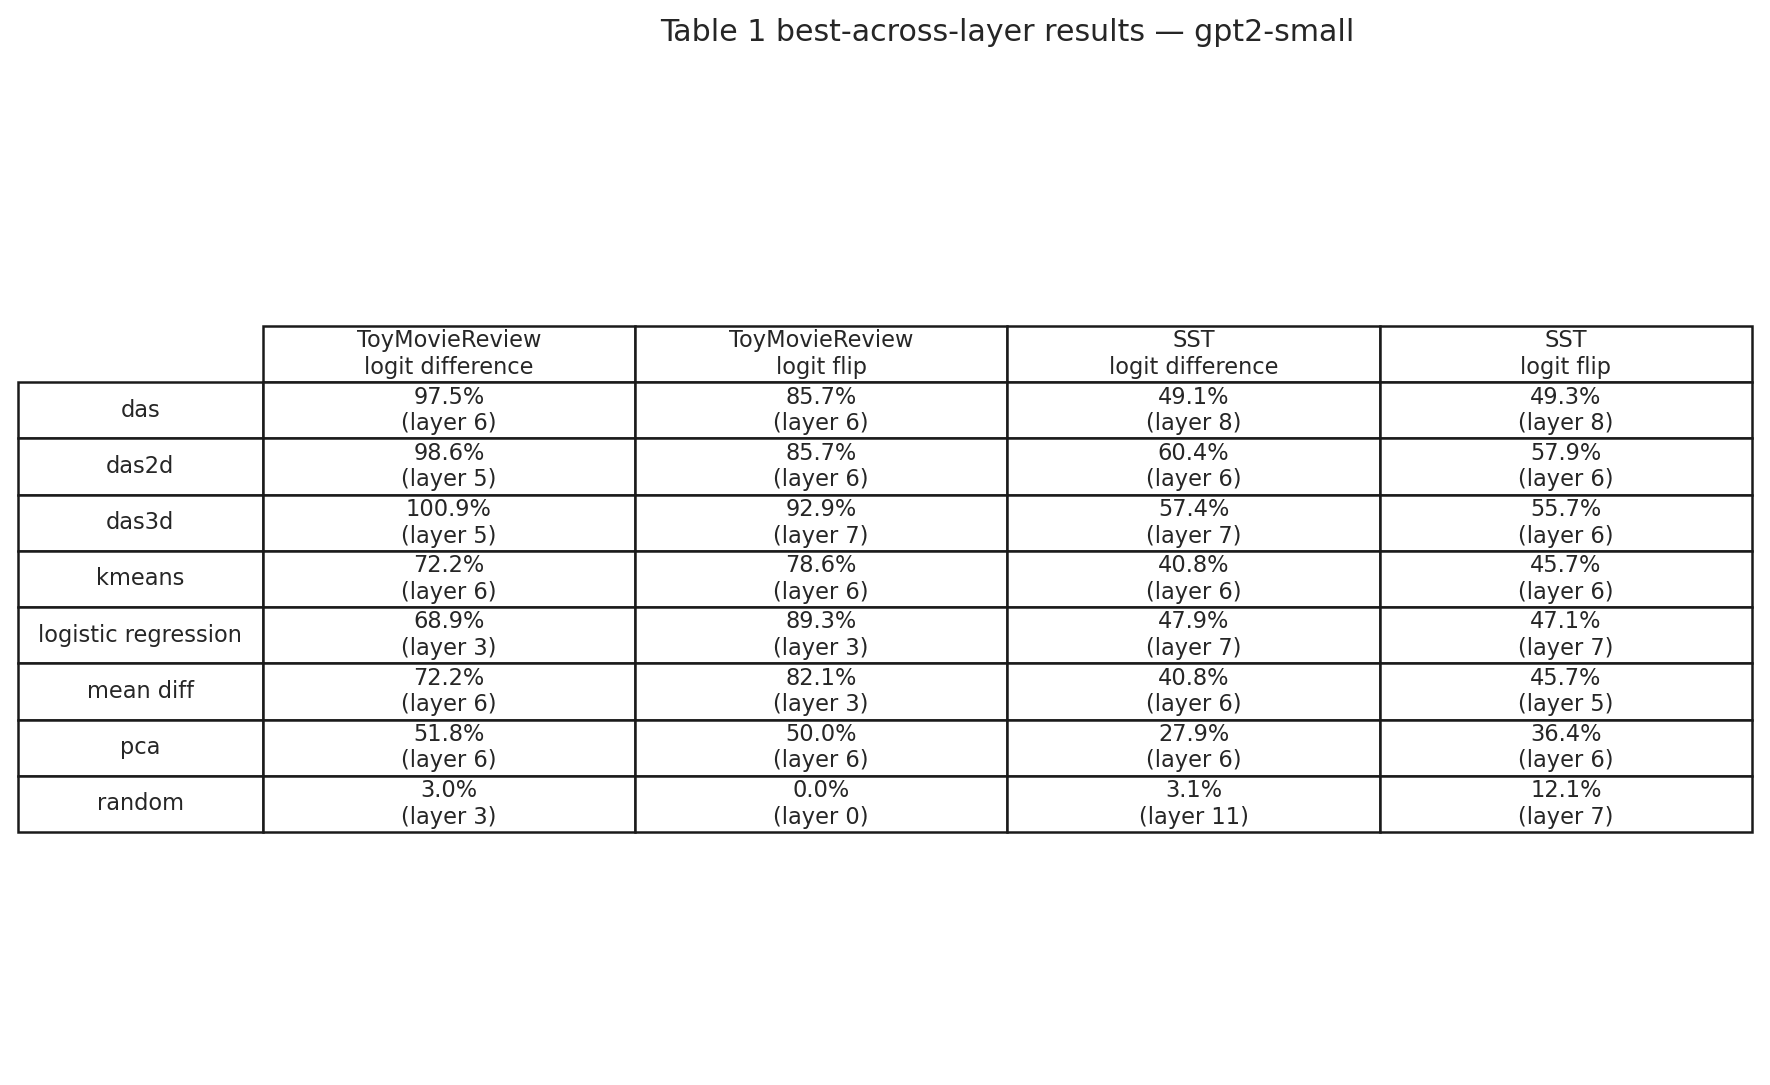

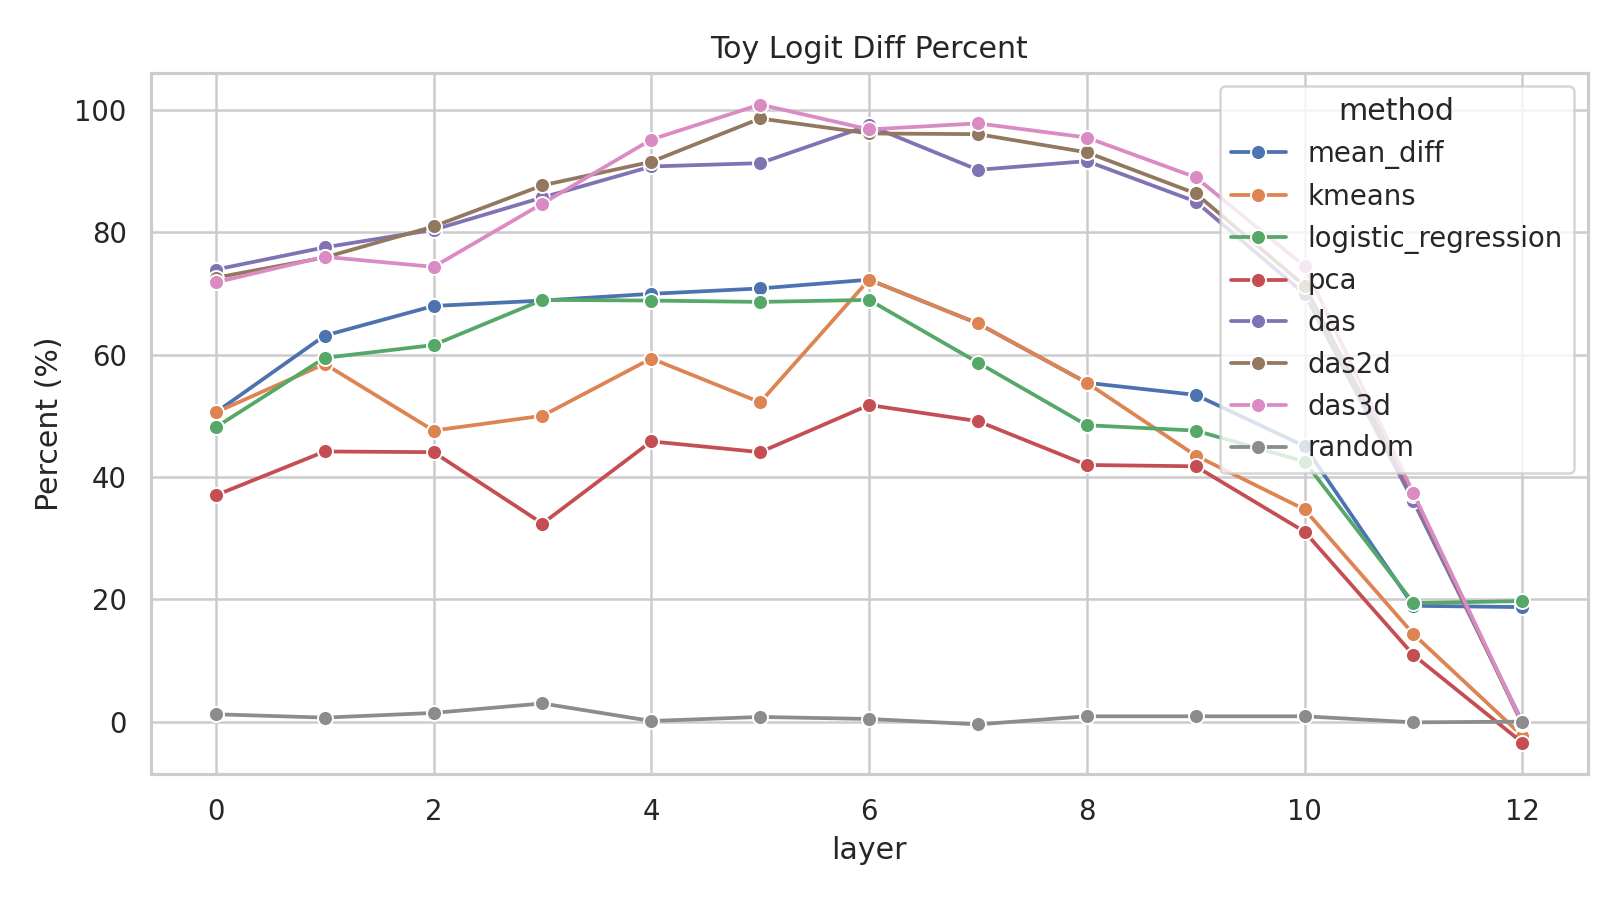

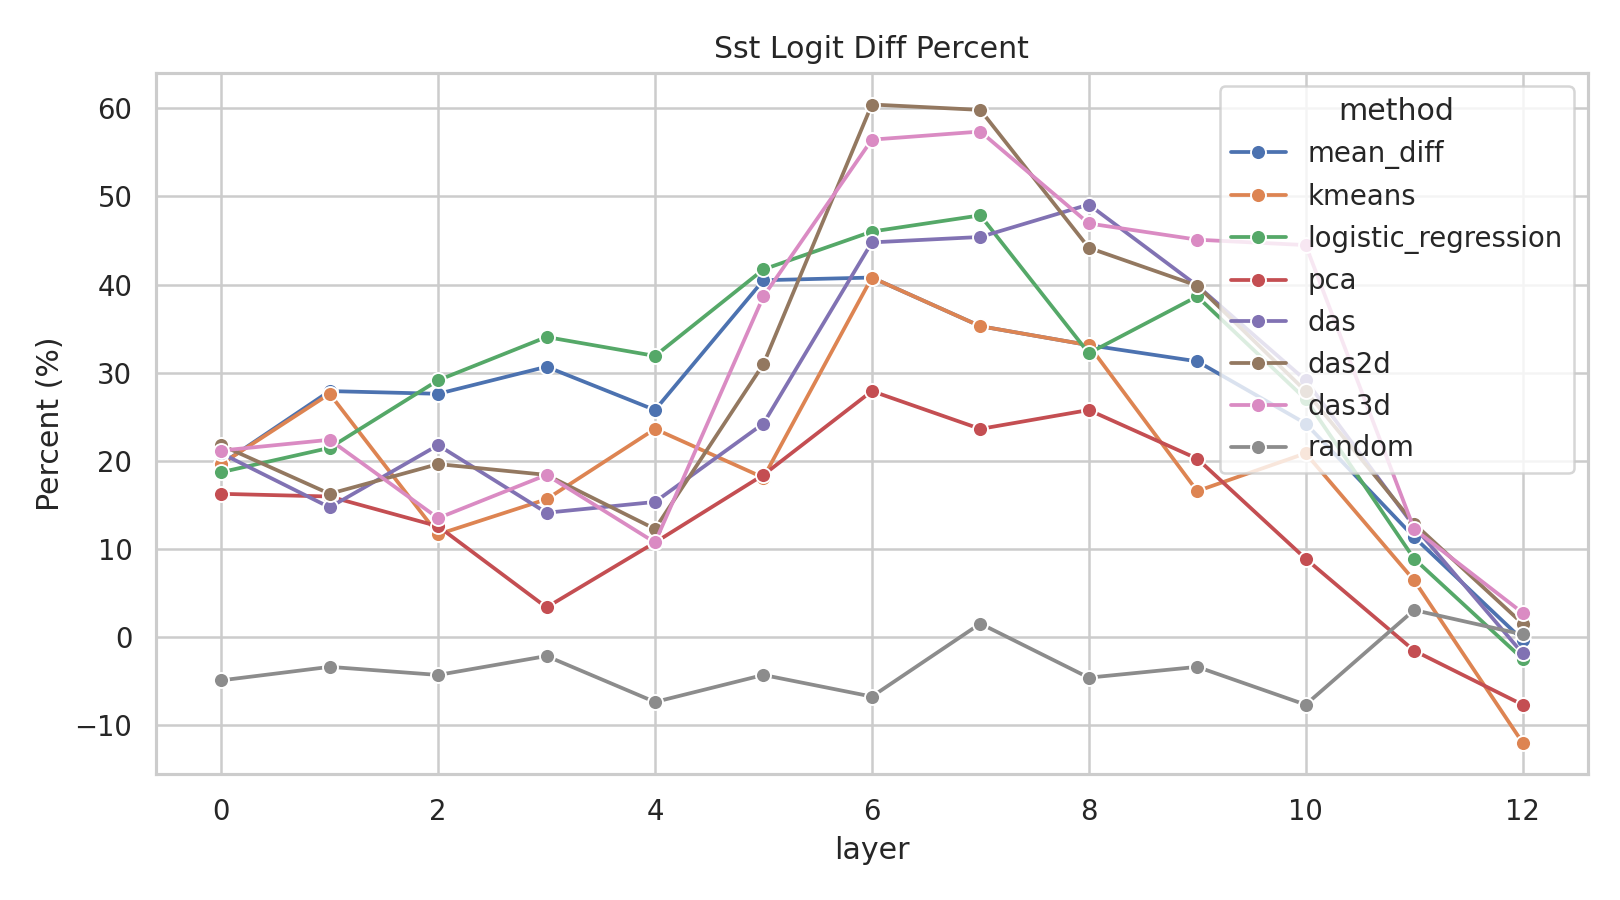

In [ ]:
import pandas as pd
from IPython.display import Image, display

if (FULL_RUN_DIR / "metrics.csv").exists() and (FULL_RUN_DIR / "best_layers.csv").exists():
    ACTIVE_RUN_DIR = FULL_RUN_DIR
elif (SMOKE_RUN_DIR / "metrics.csv").exists() and (SMOKE_RUN_DIR / "best_layers.csv").exists():
    ACTIVE_RUN_DIR = SMOKE_RUN_DIR
else:
    raise FileNotFoundError("No completed smoke or full run was found.")

print("Displaying:", ACTIVE_RUN_DIR)
metrics = pd.read_csv(ACTIVE_RUN_DIR / "metrics.csv")
best_layers = pd.read_csv(ACTIVE_RUN_DIR / "best_layers.csv")
directions = pd.read_csv(ACTIVE_RUN_DIR / "direction_metadata.csv")
patching = pd.read_csv(ACTIVE_RUN_DIR / "patching_records.csv")

display(best_layers)
display(metrics.head())
display(directions[[column for column in ["method", "layer", "subspace_dimension", "artifact_path"] if column in directions.columns]].head(20))
display(
    patching.groupby(["dataset", "method", "layer"], as_index=False)
    .size()
    .rename(columns={"size": "patched_pairs"})
    .head(30)
)

for figure_name in [
    "table1_best_results.png",
    "toy_logit_diff_percent_by_layer.png",
    "sst_logit_diff_percent_by_layer.png",
]:
    figure_path = ACTIVE_RUN_DIR / "figures" / figure_name
    if figure_path.exists():
        display(Image(filename=str(figure_path)))

## Qwen results

Displaying: /content/sentiment-manifold/outputs/colab/full/qwen-0.6b


,model,method,dataset,metric,metric_column,layer,value_percent
0,qwen-0.6b,das,toy_movie_review,logit_difference,toy_logit_diff_percent,12,97.812692
1,qwen-0.6b,das,toy_movie_review,logit_flip,toy_logit_flip_percent,11,100.000000
2,qwen-0.6b,das,sst,logit_difference,sst_logit_diff_percent,17,48.451429
3,qwen-0.6b,das,sst,logit_flip,sst_logit_flip_percent,17,50.480768
4,qwen-0.6b,das2d,toy_movie_review,logit_difference,toy_logit_diff_percent,11,92.459957
5,qwen-0.6b,das2d,toy_movie_review,logit_flip,toy_logit_flip_percent,11,100.000000
6,qwen-0.6b,das2d,sst,logit_difference,sst_logit_diff_percent,17,49.969259
7,qwen-0.6b,das2d,sst,logit_flip,sst_logit_flip_percent,17,53.846150
8,qwen-0.6b,das3d,toy_movie_review,logit_difference,toy_logit_diff_percent,11,95.848735
9,qwen-0.6b,das3d,toy_movie_review,logit_flip,toy_logit_flip_percent,11,100.000000


,model,method,layer,subspace_dimension,toy_projection_accuracy,toy_patch_recovery,toy_flip_rate,toy_sign_flip_rate,toy_logit_diff_percent,toy_logit_flip_percent,...,sst_sign_flip_rate,sst_logit_diff_percent,sst_logit_flip_percent,sst_sign_flip_percent,sst_corrupted_accuracy,sst_clean_accuracy,sst_patched_accuracy,n_toy_test,n_sst,n_sst_pairs
0,qwen-0.6b,mean_diff,0,1,0.933333,0.351433,0.321429,0.392857,35.143256,32.142857,...,0.033784,5.006917,2.403846,3.378378,0.031532,0.968468,0.054054,30,1236,444
1,qwen-0.6b,kmeans,0,1,0.933333,0.351433,0.321429,0.392857,35.143256,32.142857,...,0.033784,5.006917,2.403846,3.378378,0.031532,0.968468,0.054054,30,1236,444
2,qwen-0.6b,logistic_regression,0,1,0.933333,0.354898,0.321429,0.392857,35.489836,32.142857,...,0.036036,5.018446,3.125000,3.603604,0.031532,0.968468,0.060811,30,1236,444
3,qwen-0.6b,pca,0,1,0.766667,0.122998,0.000000,0.000000,12.299753,0.000000,...,0.015766,2.440058,0.961538,1.576577,0.031532,0.968468,0.040541,30,1236,444
4,qwen-0.6b,das,0,1,0.933333,0.601741,0.607143,0.642857,60.174064,60.714287,...,0.042793,5.567937,3.846153,4.279279,0.031532,0.968468,0.067568,30,1236,444


,method,layer,subspace_dimension,artifact_path
0,mean_diff,0,1,/content/drive/MyDrive/sentiment-manifold/chec...
1,kmeans,0,1,/content/drive/MyDrive/sentiment-manifold/chec...
2,logistic_regression,0,1,/content/drive/MyDrive/sentiment-manifold/chec...
3,pca,0,1,/content/drive/MyDrive/sentiment-manifold/chec...
4,das,0,1,/content/drive/MyDrive/sentiment-manifold/chec...
5,das2d,0,2,/content/drive/MyDrive/sentiment-manifold/chec...
6,das3d,0,3,/content/drive/MyDrive/sentiment-manifold/chec...
7,random,0,1,/content/drive/MyDrive/sentiment-manifold/chec...
8,mean_diff,1,1,/content/drive/MyDrive/sentiment-manifold/chec...
9,kmeans,1,1,/content/drive/MyDrive/sentiment-manifold/chec...


,dataset,method,layer,patched_pairs
0,sst,das,0,444
1,sst,das,1,444
2,sst,das,2,444
3,sst,das,3,444
4,sst,das,4,444
5,sst,das,5,444
6,sst,das,6,444
7,sst,das,7,444
8,sst,das,8,444
9,sst,das,9,444


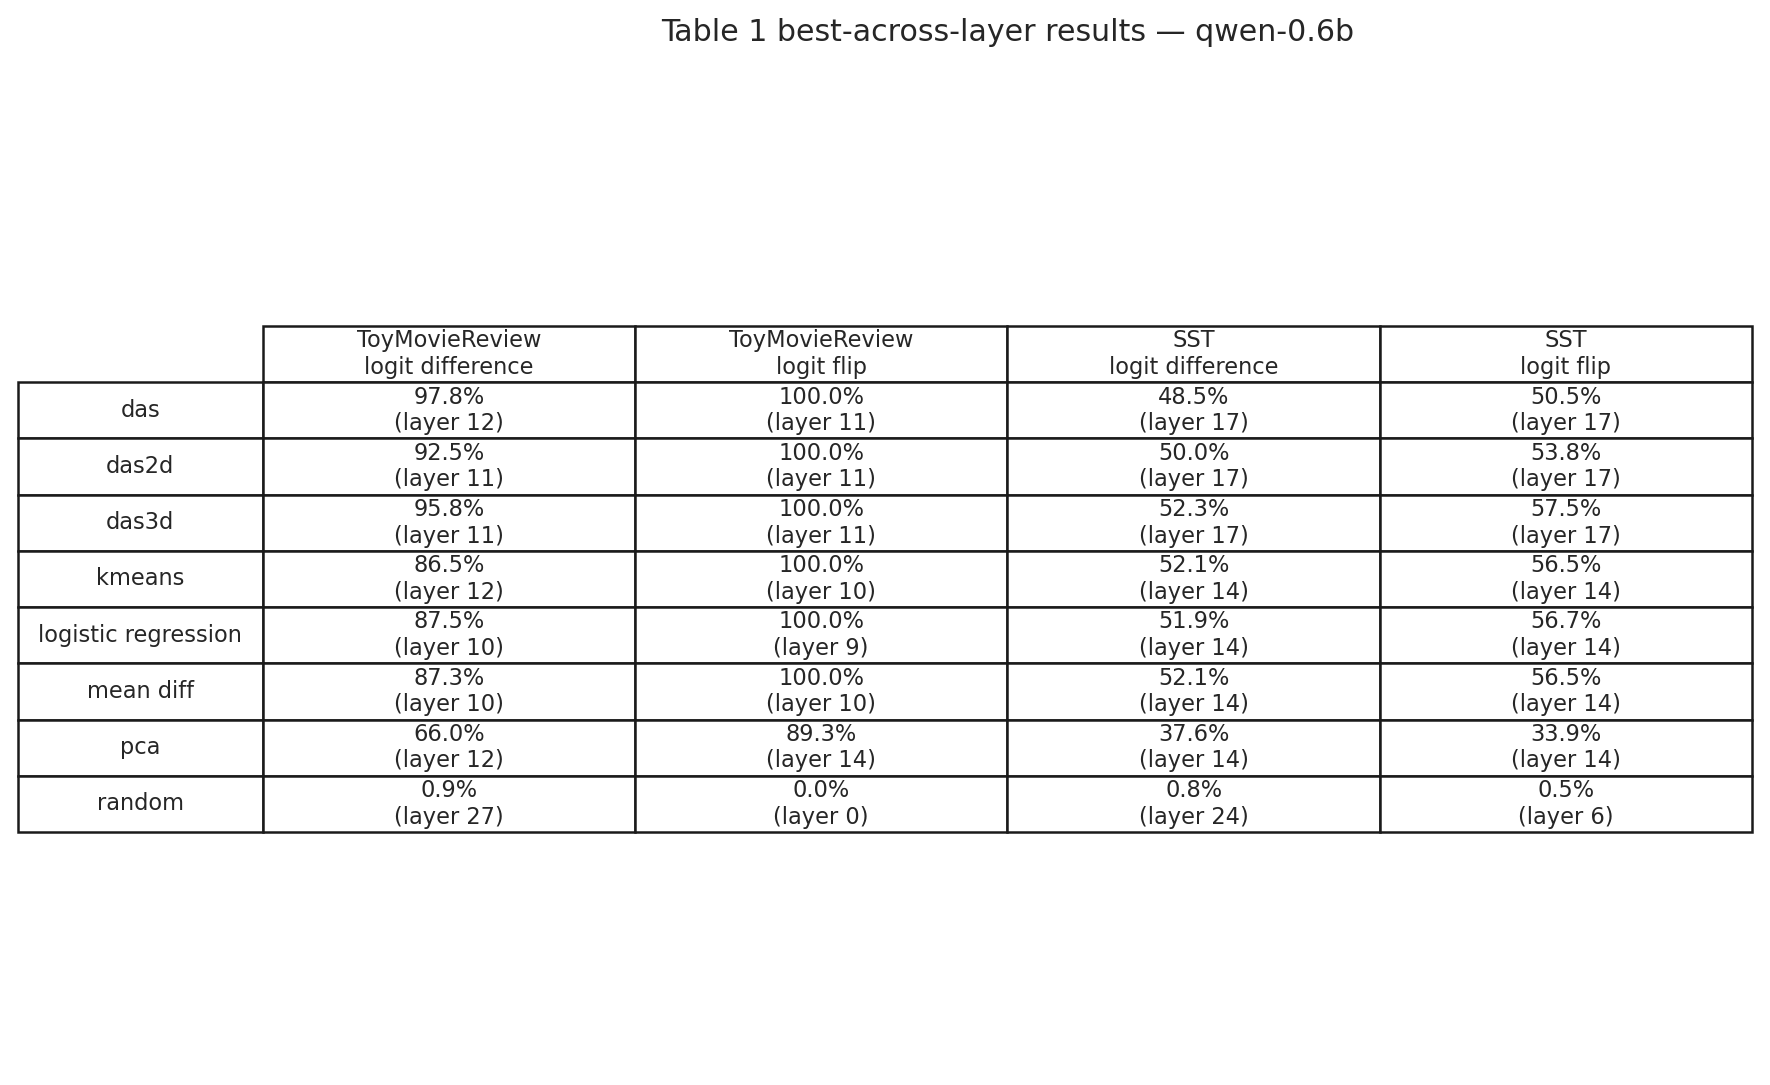

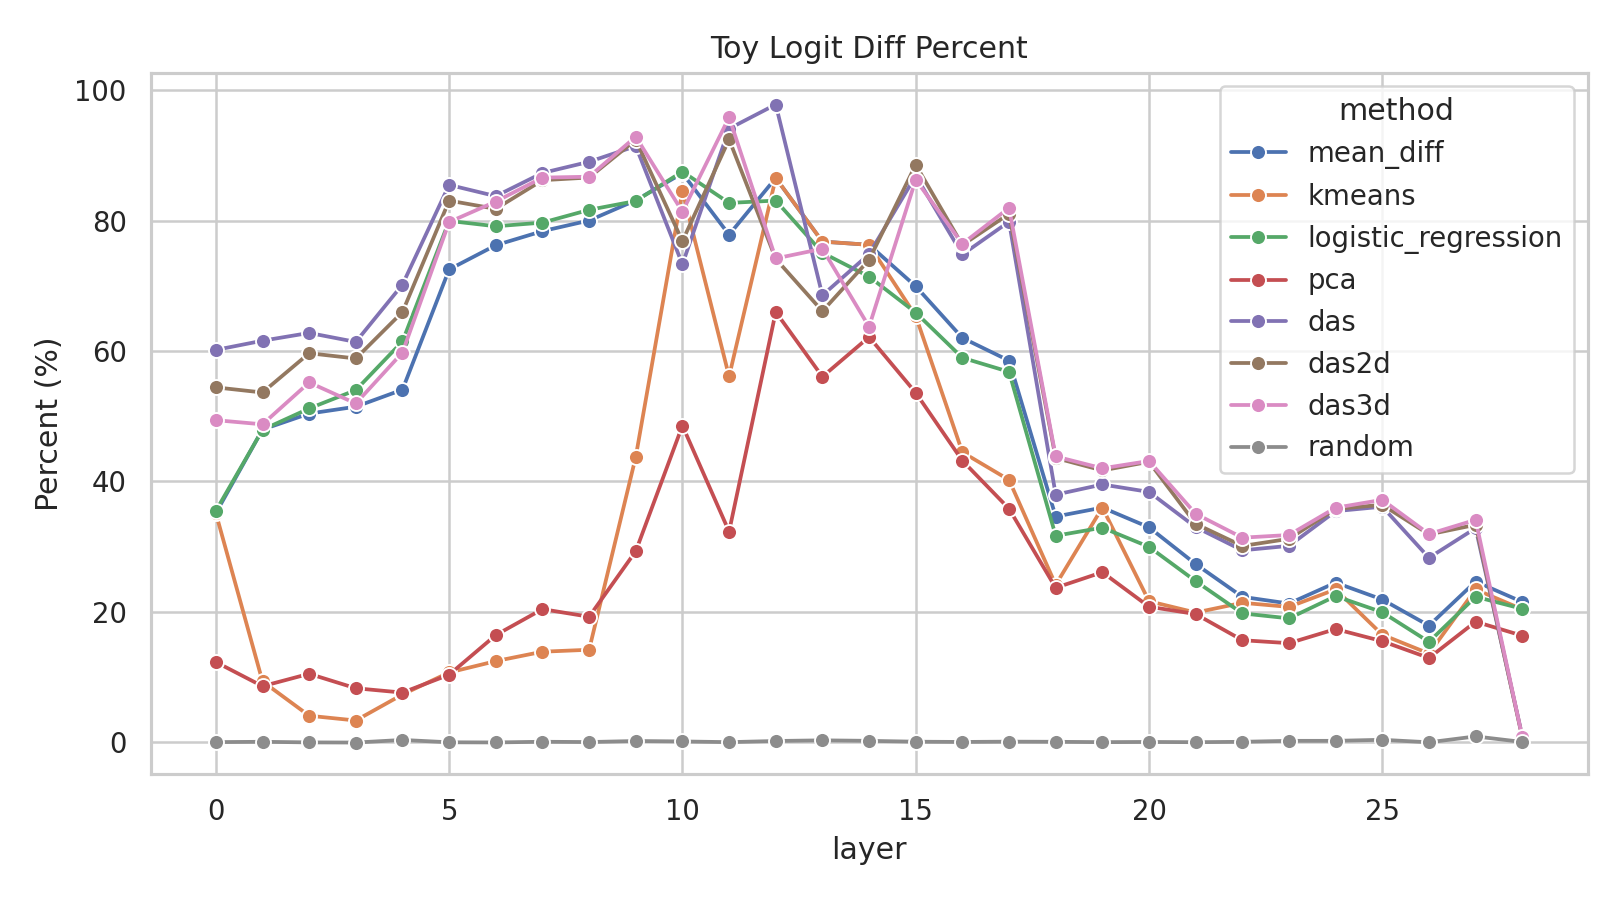

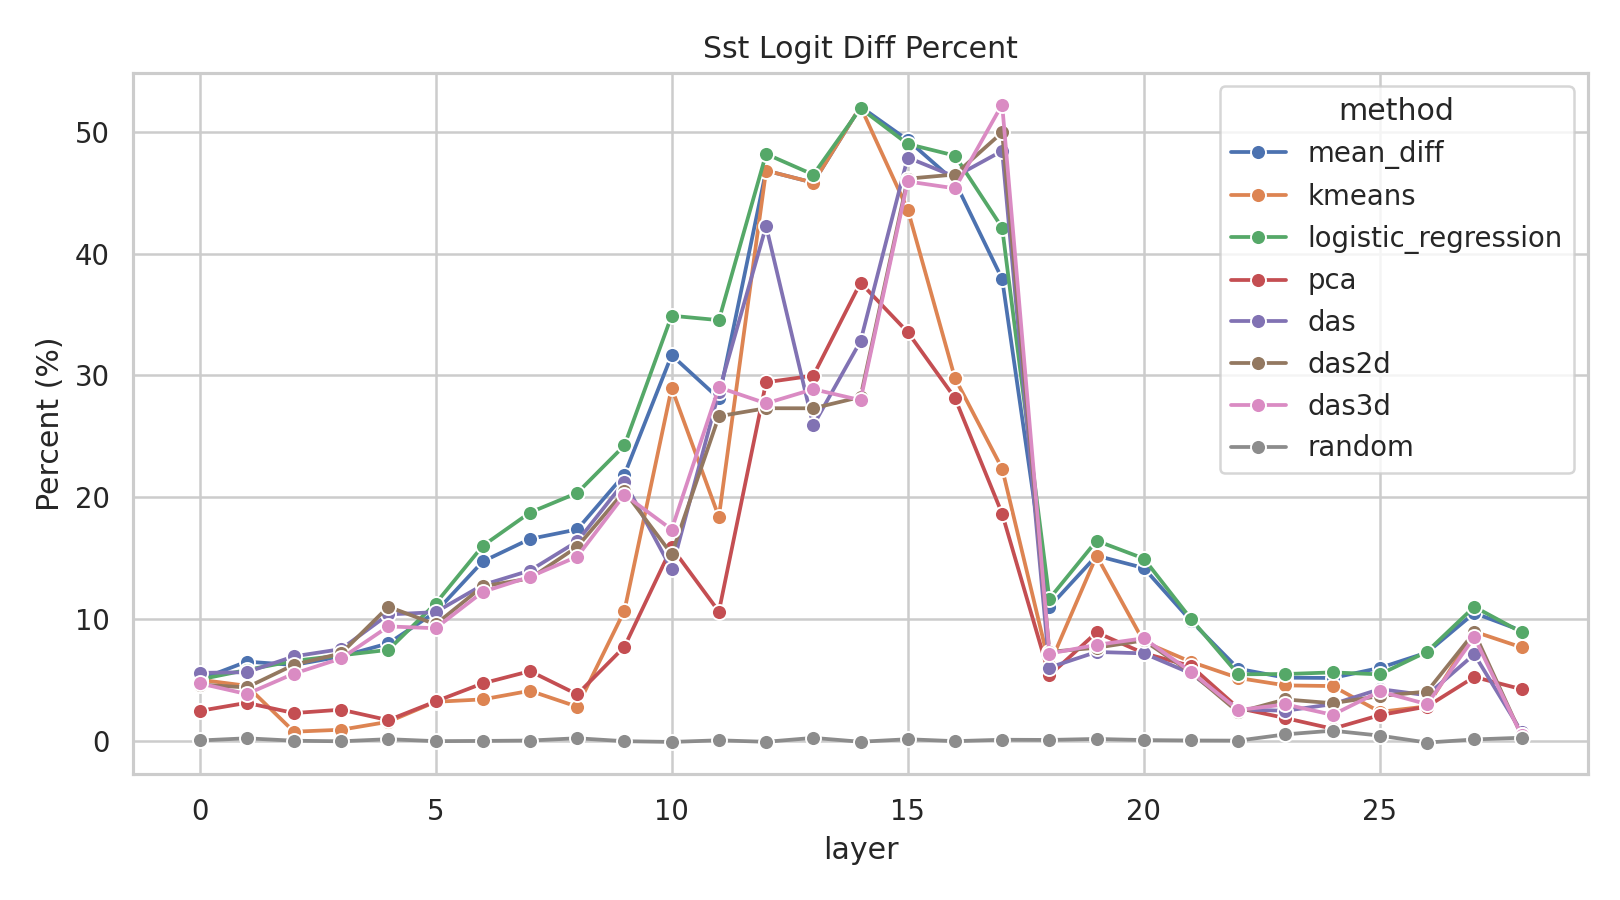

In [34]:
import pandas as pd
from IPython.display import Image, display

if (FULL_RUN_DIR / "metrics.csv").exists() and (FULL_RUN_DIR / "best_layers.csv").exists():
    ACTIVE_RUN_DIR = FULL_RUN_DIR
elif (SMOKE_RUN_DIR / "metrics.csv").exists() and (SMOKE_RUN_DIR / "best_layers.csv").exists():
    ACTIVE_RUN_DIR = SMOKE_RUN_DIR
else:
    raise FileNotFoundError("No completed smoke or full run was found.")

print("Displaying:", ACTIVE_RUN_DIR)
metrics = pd.read_csv(ACTIVE_RUN_DIR / "metrics.csv")
best_layers = pd.read_csv(ACTIVE_RUN_DIR / "best_layers.csv")
directions = pd.read_csv(ACTIVE_RUN_DIR / "direction_metadata.csv")
patching = pd.read_csv(ACTIVE_RUN_DIR / "patching_records.csv")

display(best_layers)
display(metrics.head())
display(directions[[column for column in ["method", "layer", "subspace_dimension", "artifact_path"] if column in directions.columns]].head(20))
display(
    patching.groupby(["dataset", "method", "layer"], as_index=False)
    .size()
    .rename(columns={"size": "patched_pairs"})
    .head(30)
)

for figure_name in [
    "table1_best_results.png",
    "toy_logit_diff_percent_by_layer.png",
    "sst_logit_diff_percent_by_layer.png",
]:
    figure_path = ACTIVE_RUN_DIR / "figures" / figure_name
    if figure_path.exists():
        display(Image(filename=str(figure_path)))

## 9. Verify expected artifacts and download the results

This assertion catches incomplete output before packaging. Direction checkpoints are deliberately excluded from the ZIP because they may be large and can already live on Drive.


In [27]:
expected_files = [
    "resolved_config.json",
    "prompt_manifest.csv",
    "toy_vocabulary.csv",
    "answer_tokens.csv",
    "sst_candidate_manifest.csv",
    "pair_manifest.csv",
    "direction_metadata.csv",
    "patching_records.csv",
    "metrics.csv",
    "best_layers.csv",
]
missing = [name for name in expected_files if not (ACTIVE_RUN_DIR / name).exists()]
assert not missing, f"Incomplete run; missing: {missing}"
print("Verified expected result artifacts.")

import shutil
archive_base = Path("/content") / f"{ACTIVE_RUN_DIR.parent.name}-gpt2-small-results"
archive_path = Path(shutil.make_archive(str(archive_base), "zip", ACTIVE_RUN_DIR))
print("Created:", archive_path)

try:
    from google.colab import files
    files.download(str(archive_path))
except ImportError:
    print("Download helper is available only in Colab.")


Verified expected result artifacts.
Created: /content/full-gpt2-small-results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
# Delete token from memory
_RUNTIME_SECRETS.clear()

In [36]:
_RUNTIME_SECRETS

{}

## Interpretation boundary

- The full reproduction fits directions on tokenizer-filtered ToyMovieReview **training** examples and evaluates held-out ToyMovieReview plus Pythia-filtered SST.
- `reproduce` follows the paper-parity layer sweep and reports each final metric's best layer independently. If you want leakage-safe layer/hyperparameter selection for a new claim, use the repository's separate `tune` then `confirm` workflow instead of selecting from these final-test results.
- Recovery is intentionally unclipped; values above 100% can occur.
- Random directions are causal controls. Projection or probe performance alone is not evidence that the model uses a direction.
- The optional OpenWebText resample-ablation diagnostic is disabled here and should not be described as the paper's principal OpenWebText result.
